# Exploratory Data Analysis — Email Dataset

This notebook explores the cleaned and split email dataset before model training.

**Dataset:** `data/processed/emails_clean.csv`  
**Schema:** `id, source, subject, text, label, split`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/processed/emails_clean.csv")
print(f"Total emails: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Total emails: 13233
Columns: ['id', 'source', 'subject', 'text', 'label', 'split']


,id,source,subject,text,label,split
0,nazario_phishing-2020_1,nazario,Your Wellsfargo Account and Card are Temporari...,"* * *\n\nDear Customer,\n\nYour Wellsfargo acc...",phishing,train
1,nazario_phishing-2020_4,nazario,You have 1 new order message (Via LinkedIn),jose@monkey.org\n\nYou have 1 new message\n\nK...,phishing,train
2,nazario_phishing-2020_5,nazario,Verify ownership of your account now,Update account activity\n\nHello jose@monkey.o...,phishing,train
3,nazario_phishing-2020_6,nazario,Pending incoming emails(jose@monkey.org).,**User:**\njose\n**Email:**\njose@monkey.org\n...,phishing,train
4,nazario_phishing-2020_7,nazario,Pending incoming emails(jose@monkey.org).,**User:**\njose\n**Email:**\njose@monkey.org\n...,phishing,train


## 1. Class Distribution

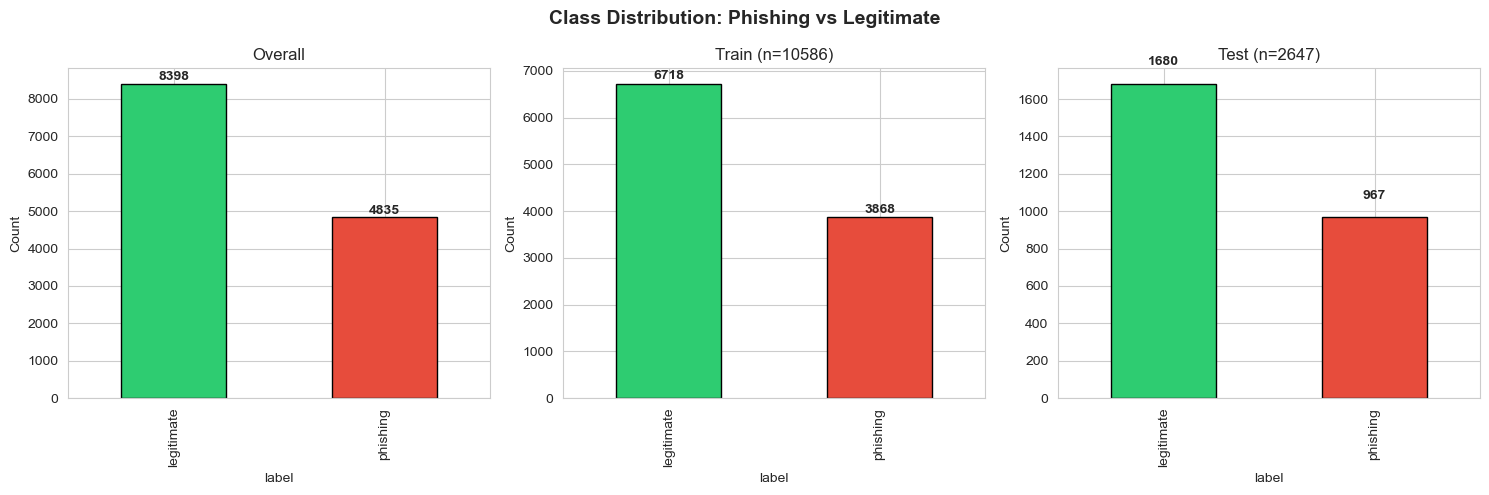

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overall
df["label"].value_counts().plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Overall")
axes[0].set_ylabel("Count")
for i, v in enumerate(df["label"].value_counts()):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Train
train = df[df["split"] == "train"]
train["label"].value_counts().plot.bar(ax=axes[1], color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[1].set_title(f"Train (n={len(train)})")
axes[1].set_ylabel("Count")
for i, v in enumerate(train["label"].value_counts()):
    axes[1].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Test
test = df[df["split"] == "test"]
test["label"].value_counts().plot.bar(ax=axes[2], color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[2].set_title(f"Test (n={len(test)})")
axes[2].set_ylabel("Count")
for i, v in enumerate(test["label"].value_counts()):
    axes[2].text(i, v + 100, str(v), ha="center", fontweight="bold")

plt.suptitle("Class Distribution: Phishing vs Legitimate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Text Length Distribution

In [3]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

# Stats table
print("Text length statistics by class:\n")
stats = df.groupby("label").agg(
    char_mean=("char_count", "mean"),
    char_median=("char_count", "median"),
    word_mean=("word_count", "mean"),
    word_median=("word_count", "median"),
    count=("char_count", "count")
).round(0)
print(stats)

Text length statistics by class:

            char_mean  char_median  word_mean  word_median  count
label                                                            
legitimate     1209.0        821.0      189.0        126.0   8398
phishing       2021.0       2046.0      323.0        328.0   4835


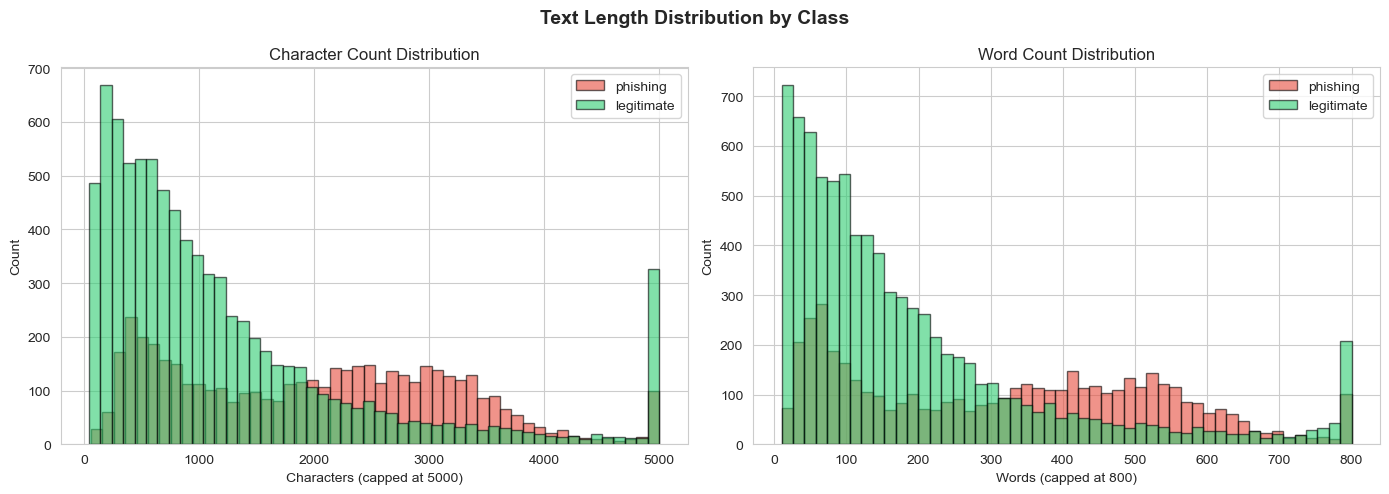

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character count histogram
for label, color in [("phishing", "#e74c3c"), ("legitimate", "#2ecc71")]:
    subset = df[df["label"] == label]
    axes[0].hist(subset["char_count"].clip(upper=5000), bins=50, alpha=0.6, label=label, color=color, edgecolor="black")
axes[0].set_title("Character Count Distribution")
axes[0].set_xlabel("Characters (capped at 5000)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Word count histogram
for label, color in [("phishing", "#e74c3c"), ("legitimate", "#2ecc71")]:
    subset = df[df["label"] == label]
    axes[1].hist(subset["word_count"].clip(upper=800), bins=50, alpha=0.6, label=label, color=color, edgecolor="black")
axes[1].set_title("Word Count Distribution")
axes[1].set_xlabel("Words (capped at 800)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Text Length Distribution by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/var/folders/_4/83ph79zn1sv_kfgmp3p3npb40000gn/T/ipykernel_3406/1687035035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="char_count", ax=axes[0], palette={"phishing": "#e74c3c", "legitimate": "#2ecc71"}, showfliers=False)
/var/folders/_4/83ph79zn1sv_kfgmp3p3npb40000gn/T/ipykernel_3406/1687035035.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="word_count", ax=axes[1], palette={"phishing": "#e74c3c", "legitimate": "#2ecc71"}, showfliers=False)


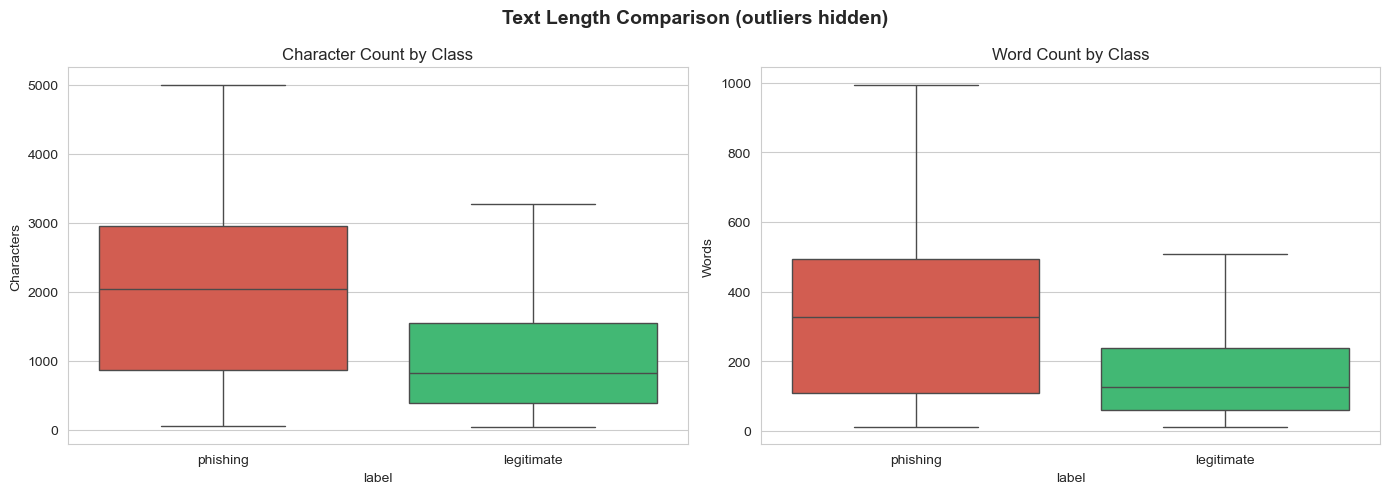

In [5]:
# Box plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="label", y="char_count", ax=axes[0], palette={"phishing": "#e74c3c", "legitimate": "#2ecc71"}, showfliers=False)
axes[0].set_title("Character Count by Class")
axes[0].set_ylabel("Characters")

sns.boxplot(data=df, x="label", y="word_count", ax=axes[1], palette={"phishing": "#e74c3c", "legitimate": "#2ecc71"}, showfliers=False)
axes[1].set_title("Word Count by Class")
axes[1].set_ylabel("Words")

plt.suptitle("Text Length Comparison (outliers hidden)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Top Words per Class

Check for obvious data leakage or class-specific vocabulary.

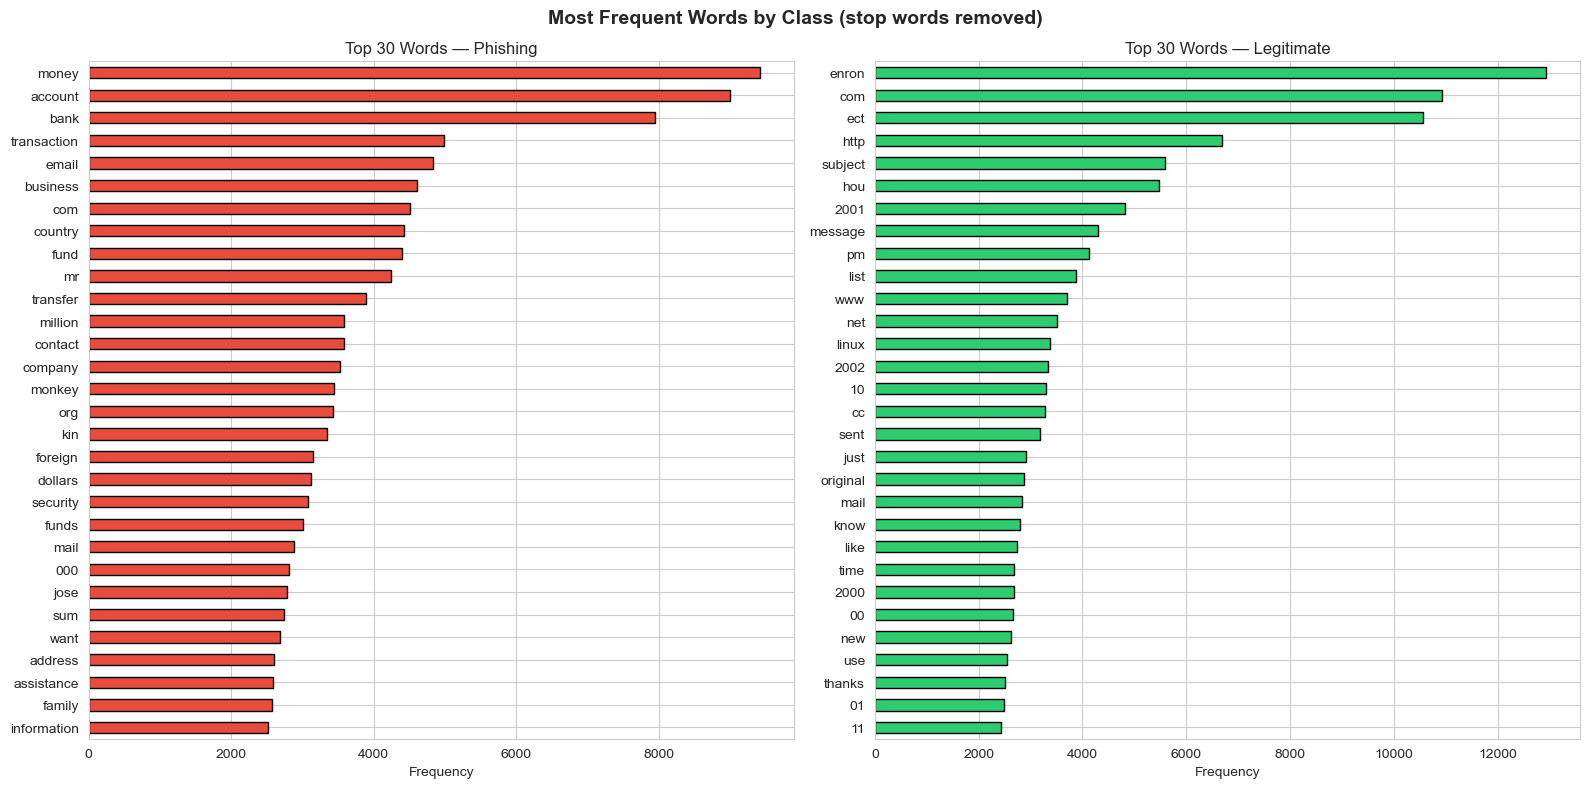

In [6]:
def get_top_words(texts, n=30):
    """Return the top n most frequent words."""
    vec = CountVectorizer(stop_words="english", max_features=n)
    X = vec.fit_transform(texts)
    word_counts = X.sum(axis=0).A1
    words = vec.get_feature_names_out()
    return pd.Series(word_counts, index=words).sort_values(ascending=False)

phishing_words = get_top_words(df[df["label"] == "phishing"]["text"])
legit_words = get_top_words(df[df["label"] == "legitimate"]["text"])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

phishing_words.plot.barh(ax=axes[0], color="#e74c3c", edgecolor="black")
axes[0].set_title("Top 30 Words — Phishing")
axes[0].set_xlabel("Frequency")
axes[0].invert_yaxis()

legit_words.plot.barh(ax=axes[1], color="#2ecc71", edgecolor="black")
axes[1].set_title("Top 30 Words — Legitimate")
axes[1].set_xlabel("Frequency")
axes[1].invert_yaxis()

plt.suptitle("Most Frequent Words by Class (stop words removed)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
# Check for potential leakage terms
leakage_terms = ["spam", "phishing", "scam", "fraud", "spamassassin", "x-spam", "ham"]
print("Leakage check — frequency of suspicious terms in email text:\n")
for term in leakage_terms:
    phish_count = df[(df["label"] == "phishing") & (df["text"].str.contains(term, case=False, na=False))].shape[0]
    legit_count = df[(df["label"] == "legitimate") & (df["text"].str.contains(term, case=False, na=False))].shape[0]
    if phish_count > 0 or legit_count > 0:
        print(f"  '{term}': phishing={phish_count}, legitimate={legit_count}")

Leakage check — frequency of suspicious terms in email text:

  'spam': phishing=117, legitimate=696
  'phishing': phishing=14, legitimate=0
  'scam': phishing=22, legitimate=29
  'fraud': phishing=43, legitimate=19
  'spamassassin': phishing=0, legitimate=417
  'x-spam': phishing=1, legitimate=14
  'ham': phishing=549, legitimate=361


## 4. Source Distribution

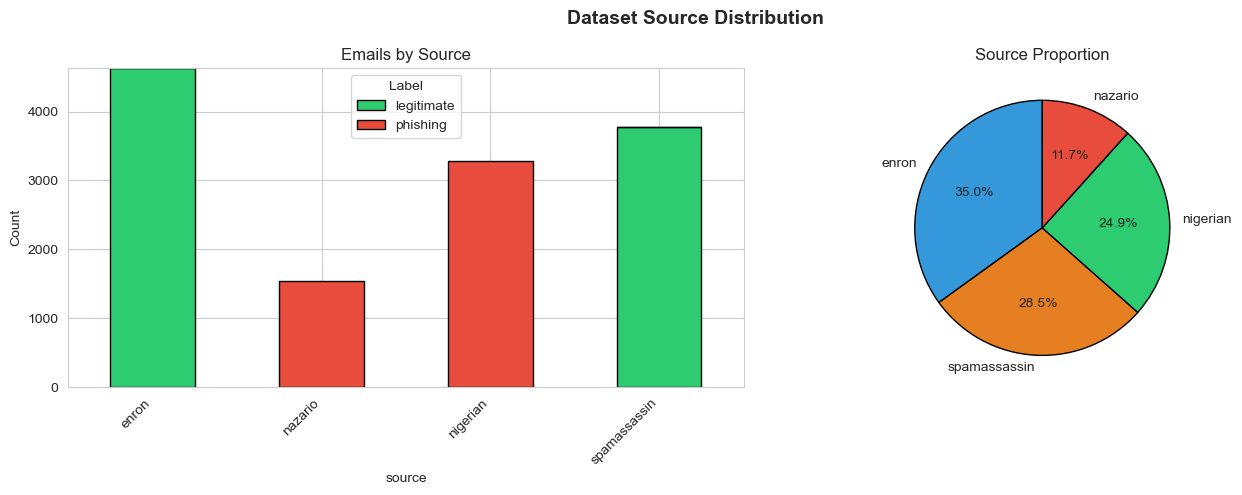


Source × Label counts:
label         legitimate  phishing
source                            
enron               4626         0
nazario                0      1546
nigerian               0      3289
spamassassin        3772         0

Source × Split counts:
split         test  train
source                   
enron          916   3710
nazario        317   1229
nigerian       650   2639
spamassassin   764   3008


In [8]:
source_label = df.groupby(["source", "label"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar by source
source_label.plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"], edgecolor="black", stacked=True)
axes[0].set_title("Emails by Source")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].legend(title="Label")

# Pie chart overall
df["source"].value_counts().plot.pie(
    ax=axes[1],
    autopct="%1.1f%%",
    colors=["#3498db", "#e67e22", "#2ecc71", "#e74c3c"],
    startangle=90,
    wedgeprops={"edgecolor": "black"}
)
axes[1].set_title("Source Proportion")
axes[1].set_ylabel("")

plt.suptitle("Dataset Source Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Table
print("\nSource × Label counts:")
print(source_label)
print(f"\nSource × Split counts:")
print(df.groupby(["source", "split"]).size().unstack(fill_value=0))

## 5. Sample Emails

Sanity check: read a few examples from each class to verify data quality.

In [9]:
def print_samples(df, label, n=5):
    print(f"\n{'='*70}")
    print(f"  SAMPLE {label.upper()} EMAILS")
    print(f"{'='*70}")
    samples = df[df["label"] == label].sample(n=n, random_state=42)
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n--- [{i}] Source: {row['source']} | Words: {len(row['text'].split())} ---")
        print(f"Subject: {row['subject']}")
        print(f"Body: {row['text'][:300]}")
        if len(row["text"]) > 300:
            print("[...]")

print_samples(df, "phishing", n=5)
print_samples(df, "legitimate", n=5)


  SAMPLE PHISHING EMAILS

--- [1] Source: nigerian | Words: 424 ---
Subject: VERY URGENT!!!
Body: DEAN GRAY
CALLE SEVILLA 112,
28001,MADRID- SPAIN
TELL:+34 639 446 879
PRIVATE E-MAIL:deangray@lycos.es
PROPOSITION:
Dear ,
I am Mr.Dean Gray, the Auditor General of a reputable bank in Spain ,
during the course of our auditing I discovered a floating fund in an
account opened in the bank in 1990 and
[...]

--- [2] Source: nigerian | Words: 289 ---
Subject: BUSINESS RELATION.
Body: >From the Desk of: DR. YINKA CRAIG.

URGENT BUSINESS PROPOSAL

I AM A SENIOR ACCOUNTANT WITH THE NIGERIAN LIQUIFIED NATURAL GAS (NLNG) HERE IN LAGOS. I

HAVE BEEN ASSIGNED BY MY COLLEAGUES TO SEEK FOR A FOREIGN PARTNER WHO WILL ASSIST US IN THE

TRANSFER OF THE SUM OF US$27.5M (TWENTY SEVEN MILLION,
[...]

--- [3] Source: nazario | Words: 53 ---
Subject: RE: Tax Invoice, remittance notice FYI.
Body: ****** monkey.org Voicemail Notification
You have received a new voice message
From: Accounts Payable Team
Title: 

## 6. Summary

Quick reference table for the dataset.

In [10]:
print(f"{'='*50}")
print(f"DATASET SUMMARY")
print(f"{'='*50}")
print(f"Total emails:     {len(df)}")
print(f"Train set:        {(df['split']=='train').sum()}")
print(f"Test set:         {(df['split']=='test').sum()}")
print(f"Phishing:         {(df['label']=='phishing').sum()} ({(df['label']=='phishing').mean()*100:.1f}%)")
print(f"Legitimate:       {(df['label']=='legitimate').sum()} ({(df['label']=='legitimate').mean()*100:.1f}%)")
print(f"Avg word count:   {df['word_count'].mean():.0f}")
print(f"Median word count:{df['word_count'].median():.0f}")
print(f"Sources:          {', '.join(df['source'].unique())}")

# Clean up temp columns
df.drop(columns=["char_count", "word_count"], inplace=True, errors="ignore")

DATASET SUMMARY
Total emails:     13233
Train set:        10586
Test set:         2647
Phishing:         4835 (36.5%)
Legitimate:       8398 (63.5%)
Avg word count:   238
Median word count:163
Sources:          nazario, nigerian, enron, spamassassin
